In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [86]:
df=pd.read_csv("Travel.csv")

In [87]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

In [89]:
cols = df.select_dtypes(include=['object']).columns
print(cols)

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='str')


In [90]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [91]:
df['Occupation'].value_counts()

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

In [92]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [93]:
df['ProductPitched'].value_counts()

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

In [94]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [95]:
df['Designation'].value_counts()

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

In [96]:
df['Gender']=df['Gender'].replace('Fe male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Single','Unmarried')

In [97]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [98]:
##Checking Missing Values
##these are features with nan values
features_with_na=[feature for feature in df.columns if df[feature].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')    

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [99]:
##statistics on numerical columns(Null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [100]:
df.fillna({
    "Age": df.Age.median(),
    "DurationOfPitch": df.DurationOfPitch.median(),
    "NumberOfTrips": df.NumberOfTrips.median(),
    "MonthlyIncome": df.MonthlyIncome.median(),

    "NumberOfFollowups": df.NumberOfFollowups.mode()[0],
    "NumberOfChildrenVisiting": df.NumberOfChildrenVisiting.mode()[0],
    "PreferredPropertyStar": df.PreferredPropertyStar.mode()[0],

    "TypeofContact": df.TypeofContact.mode()[0]
}, inplace=True)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Unmarried,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Unmarried,3.0,0,5,0,2.0,Executive,20289.0


In [101]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [102]:
df.drop('CustomerID',inplace=True, axis=1)

In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4888 non-null   int64  
 1   Age                       4888 non-null   float64
 2   TypeofContact             4888 non-null   str    
 3   CityTier                  4888 non-null   int64  
 4   DurationOfPitch           4888 non-null   float64
 5   Occupation                4888 non-null   str    
 6   Gender                    4888 non-null   str    
 7   NumberOfPersonVisiting    4888 non-null   int64  
 8   NumberOfFollowups         4888 non-null   float64
 9   ProductPitched            4888 non-null   str    
 10  PreferredPropertyStar     4888 non-null   float64
 11  MaritalStatus             4888 non-null   str    
 12  NumberOfTrips             4888 non-null   float64
 13  Passport                  4888 non-null   int64  
 14  PitchSatisfactionSc

In [104]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [105]:
df['TotalVisiting']=df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']

In [106]:
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], inplace=True)

In [107]:
##GET ALL Numeric features
num_features=[feature for feature in df.columns if df[feature].dtype!='O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 18


In [108]:
cat_features=[ feature for feature in df.columns if df[feature].dtype=='O']
print('Num of Discrete Features :',len(cat_features))

Num of Discrete Features : 0


In [109]:
discrete_features=[feature for feature in df.columns if len(df[feature].unique())<=25]
print('Num of Numerical Features :', len(discrete_features))

Num of Numerical Features : 15


In [110]:
continous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continous features:',len(continous_features))

Num of Continous features: 3


In [111]:
X=df.drop(['ProdTaken'],axis=1)
y=df['ProdTaken']

In [112]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [113]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [114]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [115]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   str    
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   str    
 5   Gender                  4888 non-null   str    
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   str    
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   str    
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   str    
 15

In [116]:
cat_features=X.select_dtypes(include="object").columns
num_features=X.select_dtypes(exclude="object").columns

In [117]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first',handle_unknown='ignore')

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScalar",numeric_transformer,num_features)
    ]
)

In [118]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [119]:
X_train

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
4197,56.0,Self Enquiry,1,27.0,Large Business,Male,4.0,Deluxe,3.0,Married,5.0,1,1,0,Manager,24093.0,4.0
4804,55.0,Company Invited,1,8.0,Salaried,Female,4.0,Standard,3.0,Married,2.0,0,5,0,Senior Manager,29180.0,5.0
3882,24.0,Company Invited,3,16.0,Small Business,Male,4.0,Basic,5.0,Married,3.0,0,5,1,Executive,20468.0,4.0
783,36.0,Self Enquiry,1,13.0,Large Business,Female,1.0,Basic,3.0,Divorced,2.0,0,3,1,Executive,18376.0,3.0
1711,32.0,Company Invited,3,13.0,Small Business,Male,3.0,Deluxe,3.0,Married,1.0,0,4,1,Manager,22347.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2270,28.0,Company Invited,1,6.0,Small Business,Male,4.0,Basic,4.0,Married,2.0,0,4,1,Executive,17596.0,2.0
1383,36.0,Company Invited,1,15.0,Salaried,Male,1.0,Basic,4.0,Married,2.0,0,5,1,Executive,17810.0,3.0
1401,55.0,Self Enquiry,2,32.0,Salaried,Male,1.0,King,4.0,Married,5.0,1,5,1,VP,34636.0,4.0
2210,36.0,Self Enquiry,1,16.0,Salaried,Male,3.0,Basic,3.0,Married,2.0,0,5,0,Executive,22347.0,2.0


In [120]:
X_train = preprocessor.fit_transform(X_train)

In [121]:
X_test=preprocessor.transform(X_test)

In [122]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,-0.718319,1.381443,0.290505,-0.726959,0.987615,1.553019,-1.514407,-1.293993,0.111192,-0.066141
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,-0.718319,-0.886165,0.290505,-0.726959,-0.669476,-0.643907,1.412236,-1.293993,1.078130,0.644330
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.460600,0.068617,0.290505,1.776264,-0.117112,-0.643907,1.412236,0.772802,-0.577848,-0.066141
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.718319,-0.289426,-2.714452,-0.726959,-0.669476,-0.643907,-0.051085,0.772802,-0.975496,-0.776612
4,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.460600,-0.289426,-0.711148,-0.726959,-1.221840,-0.643907,0.680576,0.772802,-0.220688,-0.066141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.718319,-1.124861,0.290505,0.524652,-0.669476,-0.643907,0.680576,0.772802,-1.123759,-1.487083
3906,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.718319,-0.050730,-2.714452,0.524652,-0.669476,-0.643907,1.412236,0.772802,-1.083081,-0.776612
3907,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.371141,1.978182,-2.714452,0.524652,0.987615,1.553019,1.412236,0.772802,2.115208,-0.066141
3908,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.718319,0.068617,-0.711148,-0.726959,-0.669476,-0.643907,1.412236,-1.293993,-0.220688,-1.487083


In [123]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [124]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier,GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,roc_auc_score,classification_report,precision_score,recall_score,f1_score,confusion_matrix,mean_squared_error, mean_absolute_error, r2_score

In [125]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier":GradientBoostingClassifier(),
    "AdaBoostClassifier":AdaBoostClassifier(),
    "XGBoost":XGBClassifier()
}

for name, model in models.items():

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities (for ROC AUC)
    y_train_proba = model.predict_proba(X_train)
    y_test_proba = model.predict_proba(X_test)

    # Training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    train_roc_auc = roc_auc_score(y_train, y_train_proba[:, 1])
    # Test metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_roc_auc = roc_auc_score(y_test, y_test_proba[:, 1])

    # Print results
    print(name)

    print("Training Performance")
    print(f"- Accuracy: {train_accuracy:.4f}")
    print(f"- F1 Score: {train_f1:.4f}")
    print(f"- Precision: {train_precision:.4f}")
    print(f"- Recall: {train_recall:.4f}")
    print(f"- ROC AUC: {train_roc_auc:.4f}")

    print("-" * 40)

    print("Test Performance")
    print(f"- Accuracy: {test_accuracy:.4f}")
    print(f"- F1 Score: {test_f1:.4f}")
    print(f"- Precision: {test_precision:.4f}")
    print(f"- Recall: {test_recall:.4f}")
    print(f"- ROC AUC: {test_roc_auc:.4f}")

    print("=" * 50)


# Regression models
reg_models = {
    "AdaBoostRegressor": AdaBoostRegressor(),
    "GBRegressor": GradientBoostingRegressor()
}

for name, model in reg_models.items():

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 🔵 Training metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    # 🟢 Test metrics
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(name)

    print("Training Performance")
    print(f"- MSE: {train_mse:.4f}")
    print(f"- MAE: {train_mae:.4f}")
    print(f"- R2 Score: {train_r2:.4f}")

    print("-" * 40)

    print("Test Performance")
    print(f"- MSE: {test_mse:.4f}")
    print(f"- MAE: {test_mae:.4f}")
    print(f"- R2 Score: {test_r2:.4f}")

    print("="*40)

Logistic Regression
Training Performance
- Accuracy: 0.8430
- F1 Score: 0.8178
- Precision: 0.8273
- Recall: 0.8430
- ROC AUC: 0.8125
----------------------------------------
Test Performance
- Accuracy: 0.8589
- F1 Score: 0.8390
- Precision: 0.8409
- Recall: 0.8589
- ROC AUC: 0.8089
Decision Tree
Training Performance
- Accuracy: 1.0000
- F1 Score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC: 1.0000
----------------------------------------
Test Performance
- Accuracy: 0.9172
- F1 Score: 0.9162
- Precision: 0.9156
- Recall: 0.9172
- ROC AUC: 0.8415
Random Forest
Training Performance
- Accuracy: 1.0000
- F1 Score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC: 1.0000
----------------------------------------
Test Performance
- Accuracy: 0.9458
- F1 Score: 0.9426
- Precision: 0.9461
- Recall: 0.9458
- ROC AUC: 0.9740
GradientBoostingClassifier
Training Performance
- Accuracy: 0.8844
- F1 Score: 0.8714
- Precision: 0.8813
- Recall: 0.8844
- ROC AUC: 0.9150
----------------

In [126]:
## Hyperparamter tuning
rf_params={"max_depth":[5,8,15,None,10],
           "max_features":[5,7,"auto",8],
           "min_samples_split":[2,8,15,20],
           "n_estimators":[100,200,500,1000]}

adaboost_param={
    "n_estimators":[50,60,70.80,90],
    "learning_rate": [0.01,0.1]
}

ada_param={
    "n_estimators":[50,60,70,80],
    "loss":['linear','square','exponential']    
}

grad_parms={"loss":['log_loss','deviance','exponential'],
            "criterion":['friedmen_mse','squared_error','mse'],
            "n_estimators":[100,200,500],
            "max_depth":[5,8,15,None,10]
}

gradb_params={"loss":['squared_error','huber','absolute_error'],
              "criterion":['friedman_mse','squared_error'],
              "max_depth":[5,8,15,None,10],
              "max_features":[5,7,"sqrt","log2",8],
              "min_samples_split":[2,8,15,20],
              "n_estimators":[100,200,500,1000],
              "learning_rate": [0.01, 0.05, 0.1, 0.2]
}
xgboost={"learning_rate":[0.1,0.01],
         "max_depth":[5,8,12,20,30],
         "n_estimators":[100,200,300],
         "colsample_bytree":[0.5,0.8,1,0.3,0.4]}

In [127]:
rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'auto', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [128]:
adaboost_param

{'n_estimators': [50, 60, 70.8, 90], 'learning_rate': [0.01, 0.1]}

In [129]:
grad_parms

{'loss': ['log_loss', 'deviance', 'exponential'],
 'criterion': ['friedmen_mse', 'squared_error', 'mse'],
 'n_estimators': [100, 200, 500],
 'max_depth': [5, 8, 15, None, 10]}

In [130]:
gradb_params

{'loss': ['squared_error', 'huber', 'absolute_error'],
 'criterion': ['friedman_mse', 'squared_error'],
 'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'sqrt', 'log2', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000],
 'learning_rate': [0.01, 0.05, 0.1, 0.2]}

In [131]:
xgboost

{'learning_rate': [0.1, 0.01],
 'max_depth': [5, 8, 12, 20, 30],
 'n_estimators': [100, 200, 300],
 'colsample_bytree': [0.5, 0.8, 1, 0.3, 0.4]}

In [132]:
randomcv_models=[
       ("RF",RandomForestClassifier(),rf_params),
       ("xgboost",XGBClassifier(),xgboost)
]

In [133]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]}),
 ('xgboost',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...),
  {'lea

In [134]:
from sklearn.model_selection import RandomizedSearchCV

model_param={}
for name,model, params in randomcv_models:
    random=RandomizedSearchCV(estimator=model,
                              param_distributions=params,
                              n_iter=100,
                              cv=3,
                              verbose=2,
                              n_jobs=-1)
    random.fit(X_train,y_train)
    model_param[name]=random.best_params_

for model_name in model_param:
    print(f"-----------------Best Params for {model_name}--------------------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
-----------------Best Params for RF--------------------------------
{'n_estimators': 200, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
-----------------Best Params for xgboost--------------------------------
{'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [137]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=500, min_samples_split=2, max_features=8, max_depth=None),
    "xgboost":XGBClassifier(n_estimators= 300, max_depth= 12, learning_rate= 0.1, colsample_bytree= 0.8)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(name)

    # 🔵 If CLASSIFIER
    if "Classifier" in name or "Forest" in name:

        y_train_proba = model.predict_proba(X_train)
        y_test_proba = model.predict_proba(X_test)

        # Training metrics
        print('Model performance for Training set')
        print("-Accuracy: {:.4f}".format(accuracy_score(y_train, y_train_pred)))
        print("-F1 score: {:.4f}".format(f1_score(y_train, y_train_pred, average='weighted')))
        print("-Precision: {:.4f}".format(precision_score(y_train, y_train_pred, average='weighted')))
        print("-Recall: {:.4f}".format(recall_score(y_train, y_train_pred, average='weighted')))
        print("-ROC AUC: {:.4f}".format(roc_auc_score(y_train, y_train_proba[:, 1])))

        print("-----------------------------------------")

        # Test metrics
        print('Model performance for Test set')
        print("-Accuracy: {:.4f}".format(accuracy_score(y_test, y_test_pred)))
        print("-F1 score: {:.4f}".format(f1_score(y_test, y_test_pred, average='weighted')))
        print("-Precision: {:.4f}".format(precision_score(y_test, y_test_pred, average='weighted')))
        print("-Recall: {:.4f}".format(recall_score(y_test, y_test_pred, average='weighted')))
        print("-ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_test_proba[:, 1])))

    # 🟢 If Xgboost
    elif "xgboost" in name:
        print('Model performance for Training set')
        print("-Accuracy: {:.4f}".format(accuracy_score(y_train, y_train_pred)))
        print("-F1 score: {:.4f}".format(f1_score(y_train, y_train_pred, average='weighted')))
        print("-Precision: {:.4f}".format(precision_score(y_train, y_train_pred, average='weighted')))
        print("-Recall: {:.4f}".format(recall_score(y_train, y_train_pred, average='weighted')))
        print("-ROC AUC: {:.4f}".format(roc_auc_score(y_train, y_train_proba[:, 1])))

        print("-----------------------------------------")

        # Test metrics
        print('Model performance for Test set')
        print("-Accuracy: {:.4f}".format(accuracy_score(y_test, y_test_pred)))
        print("-F1 score: {:.4f}".format(f1_score(y_test, y_test_pred, average='weighted')))
        print("-Precision: {:.4f}".format(precision_score(y_test, y_test_pred, average='weighted')))
        print("-Recall: {:.4f}".format(recall_score(y_test, y_test_pred, average='weighted')))
        print("-ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_test_proba[:, 1])))
        
        
    else:    
        print('Model performance for Training set')
        print("-MSE: {:.4f}".format(mean_squared_error(y_train, y_train_pred)))
        print("-MAE: {:.4f}".format(mean_absolute_error(y_train, y_train_pred)))
        print("-R2 Score: {:.4f}".format(r2_score(y_train, y_train_pred)))

        print("-----------------------------------------")

        print('Model performance for Test set')
        print("-MSE: {:.4f}".format(mean_squared_error(y_test, y_test_pred)))
        print("-MAE: {:.4f}".format(mean_absolute_error(y_test, y_test_pred)))
        print("-R2 Score: {:.4f}".format(r2_score(y_test, y_test_pred)))

    print("="*50)
    print("\n")

Random Forest
Model performance for Training set
-Accuracy: 1.0000
-F1 score: 1.0000
-Precision: 1.0000
-Recall: 1.0000
-ROC AUC: 1.0000
-----------------------------------------
Model performance for Test set
-Accuracy: 0.9468
-F1 score: 0.9440
-Precision: 0.9467
-Recall: 0.9468
-ROC AUC: 0.9767


xgboost
Model performance for Training set
-Accuracy: 1.0000
-F1 score: 1.0000
-Precision: 1.0000
-Recall: 1.0000
-ROC AUC: 1.0000
-----------------------------------------
Model performance for Test set
-Accuracy: 0.9581
-F1 score: 0.9567
-Precision: 0.9576
-Recall: 0.9581
-ROC AUC: 0.9767




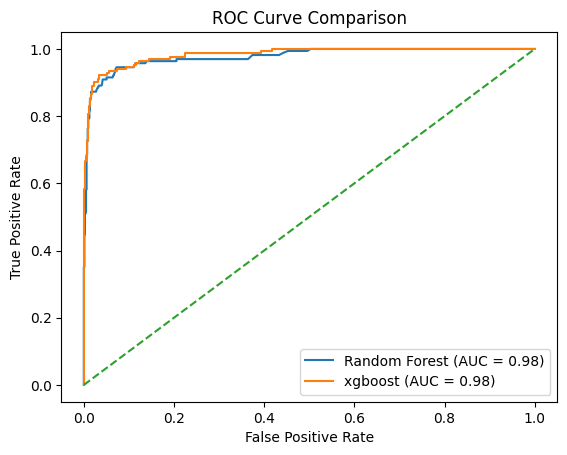

In [138]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for name, model in models.items():

    # Skip regressors
    if not hasattr(model, "predict_proba"):
        continue

    # Get probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()